# Setup

In [1]:
# standard library imports
import time

# third party library imports
import numpy as np
import optuna
import pandas as pd

# machine learning imports
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# local imports
from utils import (
    plot_confusion_matrix,
    plot_correlation_heatmap,
    plot_feature_distributions,
    plot_model_metrics,
    plot_predictions,
    plot_probability_distribution,
    plot_target_correlations,
    validate_train_test_distribution,
)

In [2]:
# patch sklearn for performance boost
from sklearnex import patch_sklearn

patch_sklearn(verbose=False)

# EDA

In [3]:
# load data
index_col = "id"
train_data = pd.read_csv("train.csv", index_col=index_col)
test_data = pd.read_csv("test.csv", index_col=index_col)
sub_data = pd.read_csv("sample_submission.csv", index_col=index_col)

In [4]:
# preview data
train_data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
id,,,,,,,,,,,,,,,,,,,,,
0,e,8.80,f,s,u,f,a,c,w,4.51,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,p,4.51,x,h,o,f,a,c,n,4.79,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,e,6.94,f,s,b,f,x,c,w,6.85,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,e,3.88,f,y,g,f,s,NaN,g,4.16,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,e,5.85,x,l,w,f,d,NaN,w,3.37,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3116940,e,9.29,f,NaN,n,t,NaN,NaN,w,12.14,...,b,NaN,w,u,w,t,g,NaN,d,u
3116941,e,10.88,s,NaN,w,t,d,c,p,6.65,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
3116942,p,7.82,x,e,e,f,a,NaN,w,9.51,...,NaN,NaN,y,NaN,w,t,z,NaN,d,a


In [5]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   class                 str    
 1   cap-diameter          float64
 2   cap-shape             str    
 3   cap-surface           str    
 4   cap-color             str    
 5   does-bruise-or-bleed  str    
 6   gill-attachment       str    
 7   gill-spacing          str    
 8   gill-color            str    
 9   stem-height           float64
 10  stem-width            float64
 11  stem-root             str    
 12  stem-surface          str    
 13  stem-color            str    
 14  veil-type             str    
 15  veil-color            str    
 16  has-ring              str    
 17  ring-type             str    
 18  spore-print-color     str    
 19  habitat               str    
 20  season                str    
dtypes: float64(3), str(18)
memory usage: 499.4 MB


In [6]:
# check for missing values in each column
train_data.isna().sum().sort_values(ascending=False)

veil-type               2957493
spore-print-color       2849682
stem-root               2757023
veil-color              2740947
stem-surface            1980861
gill-spacing            1258435
cap-surface              671023
gill-attachment          523936
ring-type                128880
gill-color                   57
habitat                      45
cap-shape                    40
stem-color                   38
has-ring                     24
cap-color                    12
does-bruise-or-bleed          8
cap-diameter                  4
class                         0
stem-width                    0
stem-height                   0
season                        0
dtype: int64

In [7]:
# check for unique values
train_data.nunique()

class                      2
cap-diameter            3913
cap-shape                 74
cap-surface               83
cap-color                 78
does-bruise-or-bleed      26
gill-attachment           78
gill-spacing              48
gill-color                63
stem-height             2749
stem-width              5836
stem-root                 38
stem-surface              60
stem-color                59
veil-type                 22
veil-color                24
has-ring                  23
ring-type                 40
spore-print-color         32
habitat                   52
season                     4
dtype: int64

In [8]:
# set target and classes
target = "class"
target_classes = [
    "e",  # editable
    "p",  # poisonous
]
train_data[target].value_counts(normalize=True) * 100

class
p    54.714
e    45.286
Name: proportion, dtype: float64

In [9]:
def encode_category(series, valid_values):
    all_values = ["missing"] + valid_values + ["other"]
    category_map = {v: i - 1 for i, v in enumerate(all_values)}

    return (
        series.fillna("missing")
        .map(category_map)
        .fillna(category_map["other"])
        .astype(np.int8)
    )


def clean_data(df):
    new_df = df.copy()

    # downcast numerical features
    for col in ["cap-diameter", "stem-height", "stem-width"]:
        new_df[col] = new_df[col].astype(np.float32)

    # impute cap-diameter values with median
    median = train_data["cap-diameter"].median()
    new_df["cap-diameter"] = new_df["cap-diameter"].fillna(median)

    # impute cap-diameter values with median
    median = train_data["stem-height"].median()
    new_df["stem-height"] = new_df["stem-height"].fillna(median)

    # encode cap-color values (109 → 13)
    cap_color_valid = ["b", "e", "g", "k", "l", "n", "o", "p", "r", "u", "w", "y"]
    new_df["cap-color"] = encode_category(new_df["cap-color"], cap_color_valid)

    # encode cap-shape values (108 → 8)
    cap_shape_valid = ["b", "c", "f", "o", "p", "s", "x"]
    new_df["cap-shape"] = encode_category(new_df["cap-shape"], cap_shape_valid)

    # encode cap-surface values (114 → 15)
    cap_surface_valid = [
        "d",
        "e",
        "f",
        "g",
        "h",
        "i",
        "k",
        "l",
        "n",
        "p",
        "s",
        "t",
        "w",
        "y",
    ]
    new_df["cap-surface"] = encode_category(new_df["cap-surface"], cap_surface_valid)

    # encode does-bruise-or-bleed values (29 → 3)
    bruise_bleed_valid = ["f", "t"]
    new_df["does-bruise-or-bleed"] = encode_category(
        new_df["does-bruise-or-bleed"], bruise_bleed_valid
    )

    # encode gill-attachment values (117 → 9)
    gill_attachment_valid = ["a", "c", "d", "e", "f", "p", "s", "x"]
    new_df["gill-attachment"] = encode_category(
        new_df["gill-attachment"], gill_attachment_valid
    )

    # encode gill-color values (86 → 13)
    gill_color_valid = ["b", "e", "f", "g", "k", "n", "o", "p", "r", "u", "w", "y"]
    new_df["gill-color"] = encode_category(new_df["gill-color"], gill_color_valid)

    # encode gill-spacing values (66 → 4)
    gill_spacing_valid = ["c", "d", "f"]
    new_df["gill-spacing"] = encode_category(new_df["gill-spacing"], gill_spacing_valid)

    # encode habitat values (65 → 9)
    habitat_valid = ["d", "g", "h", "l", "m", "p", "u", "w"]
    new_df["habitat"] = encode_category(new_df["habitat"], habitat_valid)

    # encode has-ring values (26 → 3)
    has_ring_valid = ["f", "t"]
    new_df["has-ring"] = encode_category(new_df["has-ring"], has_ring_valid)

    # encode ring-type values (47 → 3)
    ring_type_valid = ["e", "f", "g", "l", "m", "p", "r", "t", "z"]
    new_df["ring-type"] = encode_category(new_df["ring-type"], ring_type_valid)

    # encode season values (4 → 4)
    season_valid = ["a", "s", "u", "w"]
    new_df["season"] = encode_category(new_df["season"], season_valid)

    # encode spore-print-color values (43 → 8)
    spore_color_valid = ["g", "k", "n", "p", "r", "u", "w"]
    new_df["spore-print-color"] = encode_category(
        new_df["spore-print-color"], spore_color_valid
    )

    # encode stem-color values (88 → 14)
    stem_color_valid = ["b", "e", "f", "g", "k", "l", "n", "o", "p", "r", "u", "w", "y"]
    new_df["stem-color"] = encode_category(new_df["stem-color"], stem_color_valid)

    # encode stem-root values (45 → 6)
    stem_root_valid = ["b", "c", "f", "r", "s"]
    new_df["stem-root"] = encode_category(new_df["stem-root"], stem_root_valid)

    # encode stem-surface values (87 → 9)
    stem_surface_valid = ["f", "g", "h", "i", "k", "s", "t", "y"]
    new_df["stem-surface"] = encode_category(new_df["stem-surface"], stem_surface_valid)

    # encode veil-color values (27 → 7)
    veil_color_valid = ["e", "k", "n", "u", "w", "y"]
    new_df["veil-color"] = encode_category(new_df["veil-color"], veil_color_valid)

    # encode veil-type values (24 → 2)
    veil_type_valid = ["u"]
    new_df["veil-type"] = encode_category(new_df["veil-type"], veil_type_valid)

    return new_df


train_data = clean_data(train_data)
test_data = clean_data(test_data)

In [10]:
# set features
numerical_features = [
    "cap-diameter",
    "stem-height",
    "stem-width",
]
nominal_features = [
    "season",
]
ordinal_features = [
    "cap-color",
    "cap-shape",
    "cap-surface",
    "does-bruise-or-bleed",
    "gill-attachment",
    "gill-color",
    "gill-spacing",
    "habitat",
    "has-ring",
    "ring-type",
    "spore-print-color",
    "stem-color",
    "stem-root",
    "stem-surface",
    "veil-color",
    "veil-type",
]

categorical_features = nominal_features + ordinal_features
features = numerical_features + categorical_features

plot_features = sorted(numerical_features + categorical_features)
corr_features = [target] + sorted(numerical_features + ordinal_features)

In [11]:
# use copies for exploratory analysis
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()

# encode target
target_encoder = LabelEncoder().fit(train_data[target])
train_data_encoded[target] = np.asarray(target_encoder.transform(train_data[target]))

# encode categorical features
categorical_encoders = {}
for feature in categorical_features:
    encoder = OrdinalEncoder().fit(train_data[[feature]])
    train_data_encoded[feature] = encoder.transform(train_data[[feature]])
    test_data_encoded[feature] = encoder.transform(test_data[[feature]])
    categorical_encoders[feature] = encoder

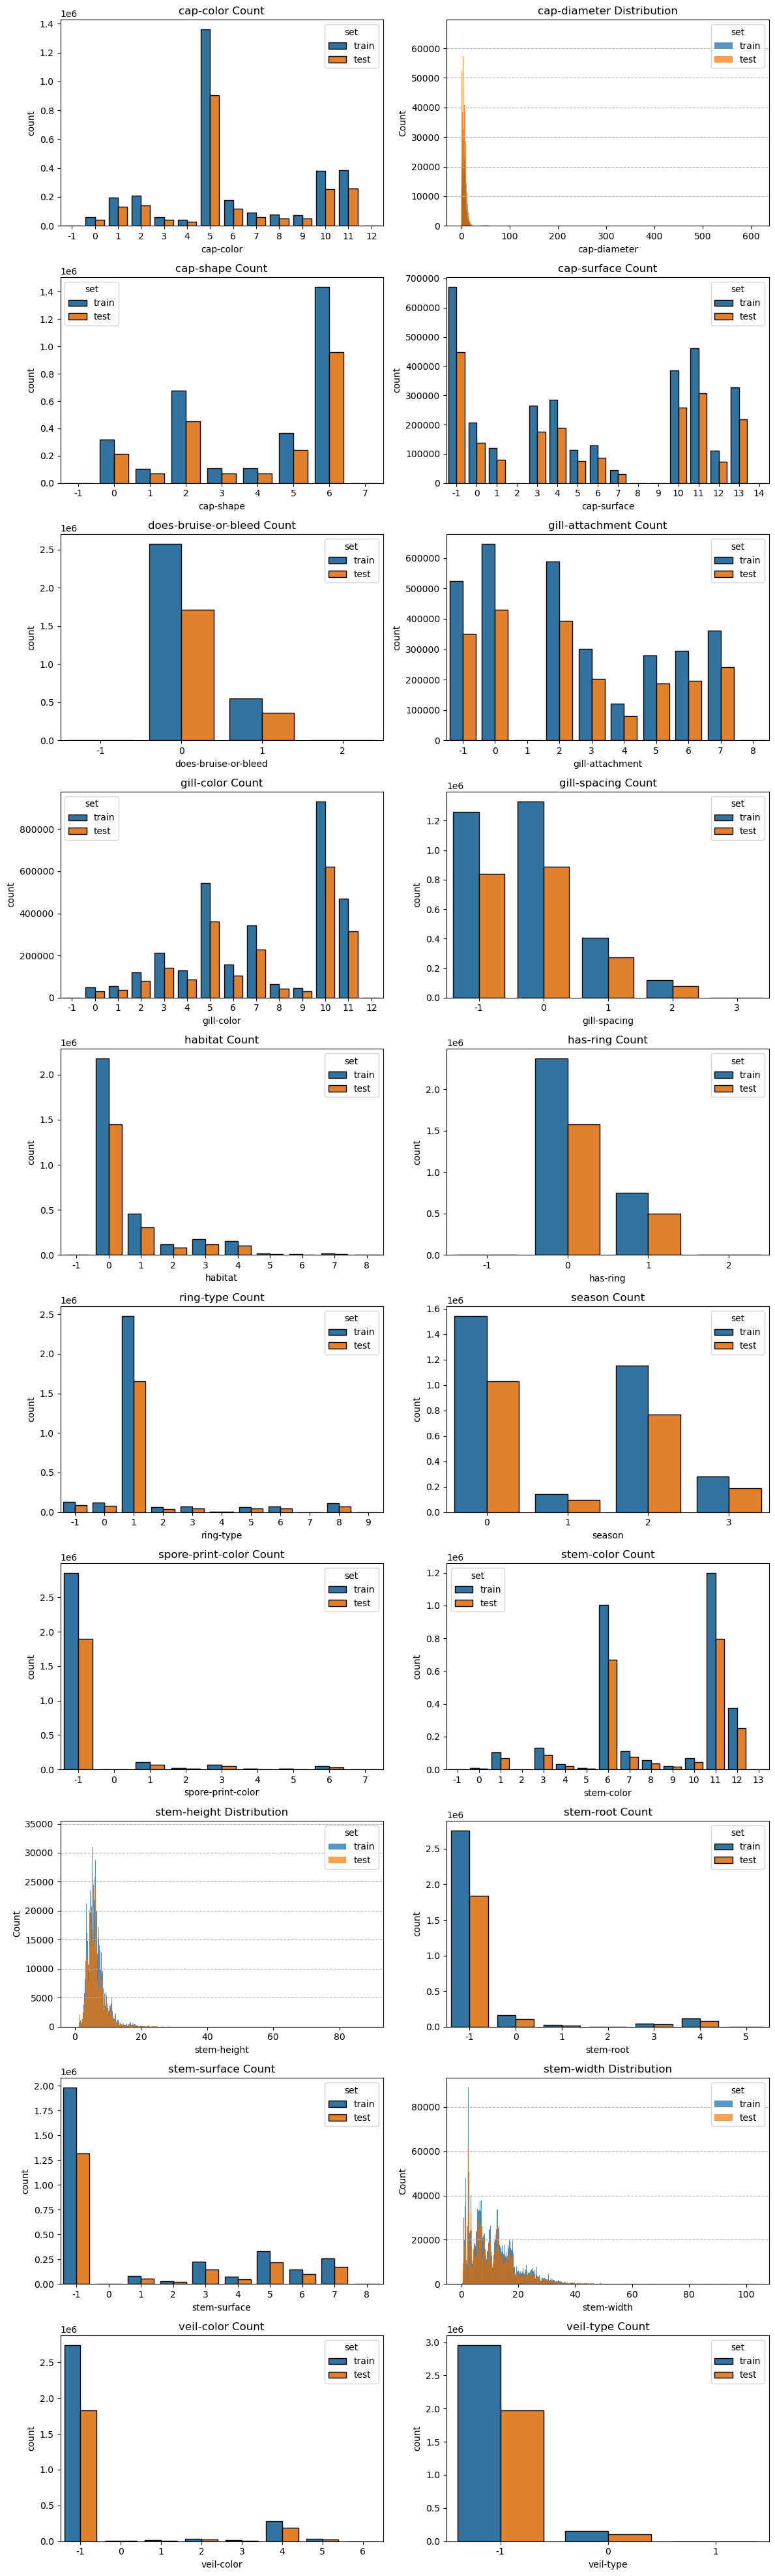

In [12]:
# plot features
plot_feature_distributions(
    train_data=train_data,
    test_data=test_data,
    features=plot_features,
    categorical_features=categorical_features,
)

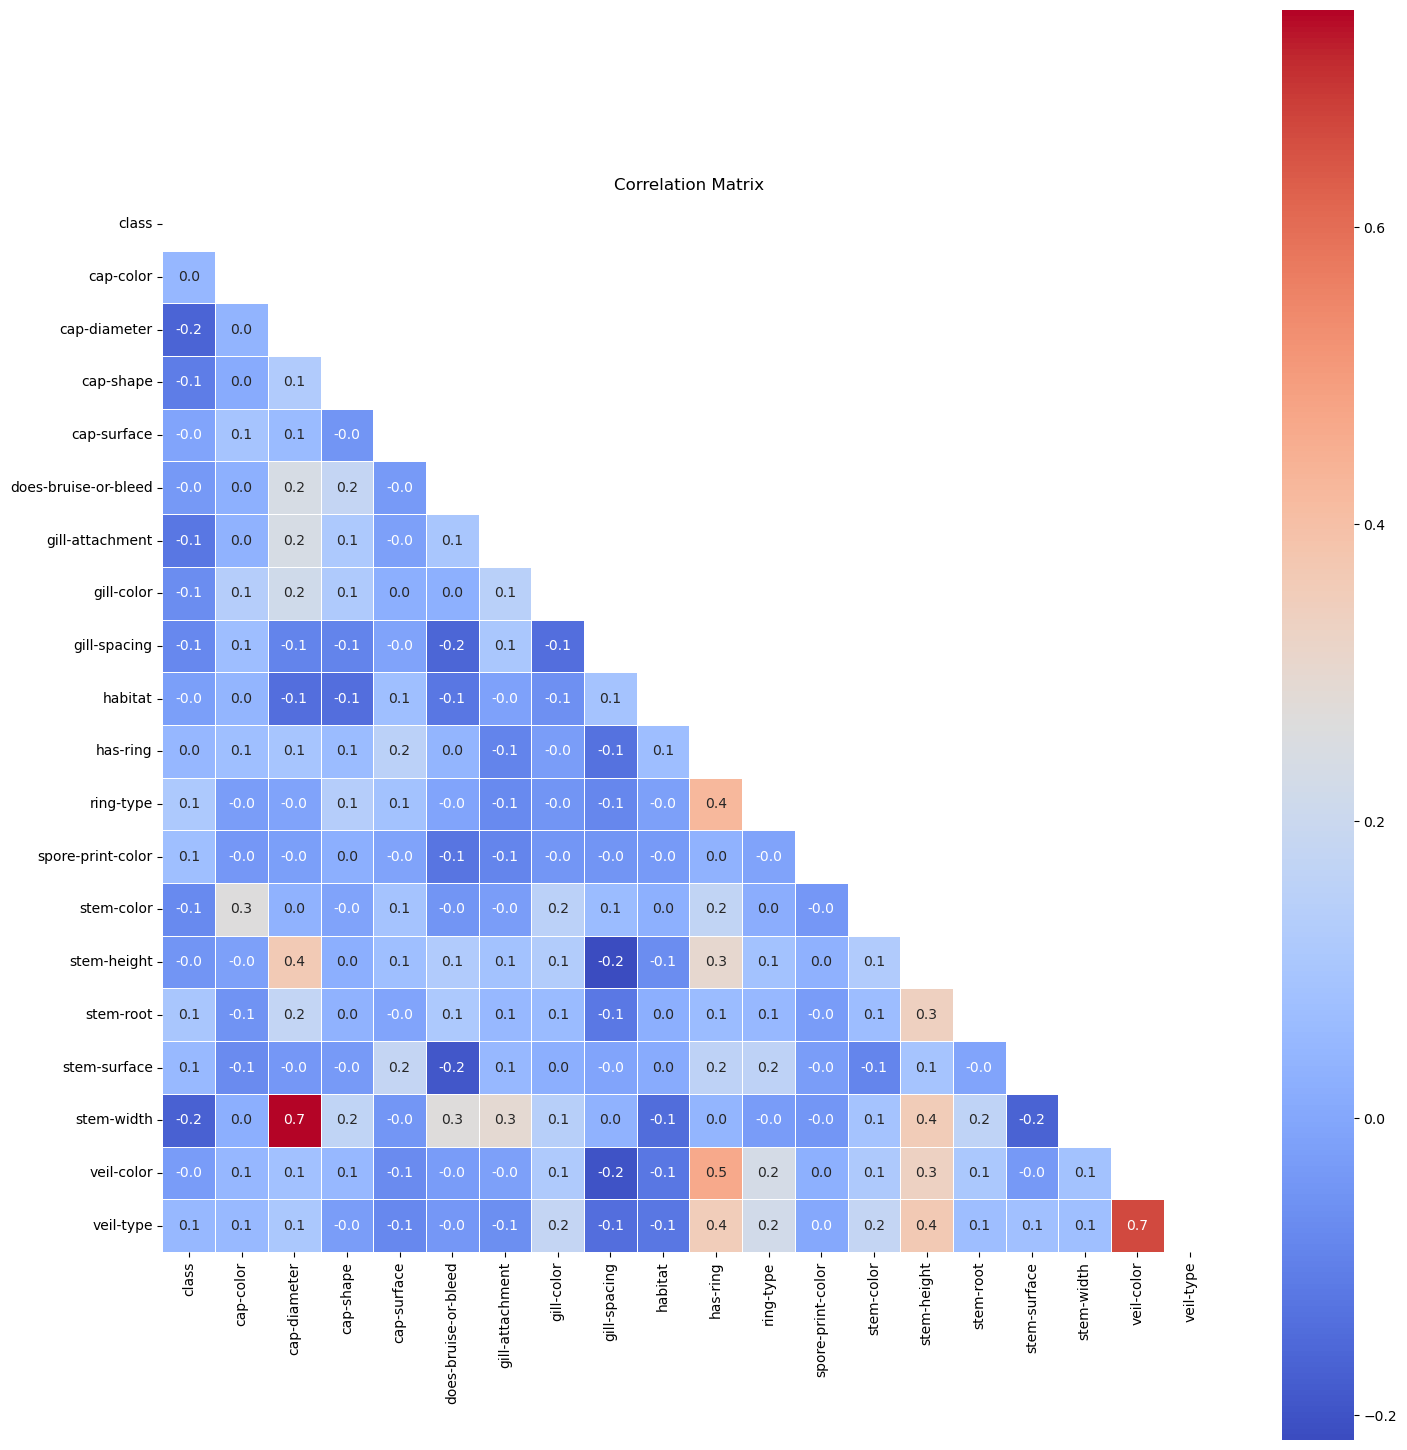

In [13]:
# plot correlations
plot_correlation_heatmap(train_data=train_data_encoded, features=corr_features)

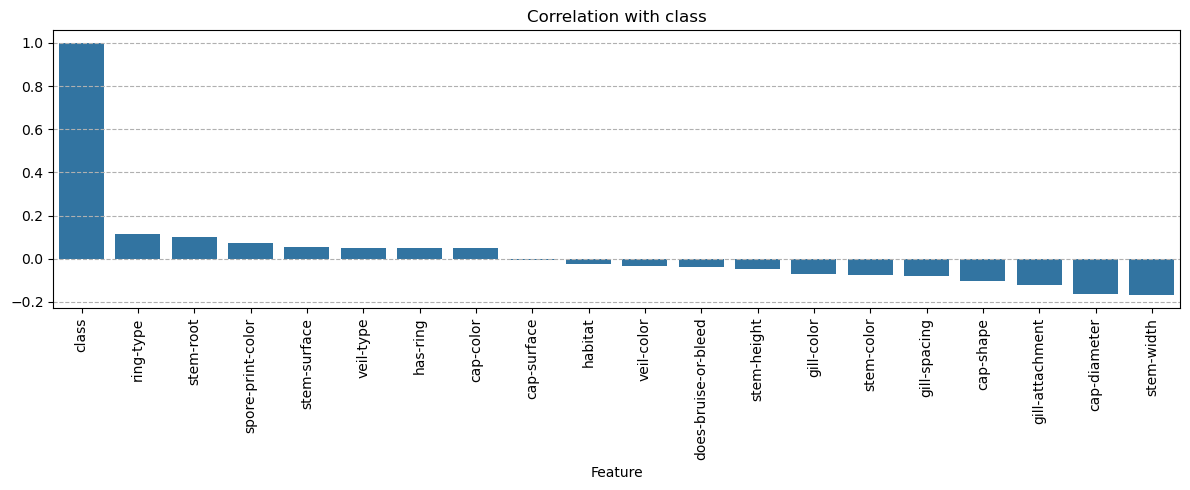

In [14]:
# plot target correlations
plot_target_correlations(
    train_data=train_data_encoded, target=target, features=corr_features
)

In [15]:
# too slow - validate that train and test sets have similar distributions
validate_train_test_distribution(
    train_data=train_data_encoded,
    test_data=test_data_encoded,
    features=plot_features,
    model=LGBMClassifier(random_state=42, n_estimators=50),
    cv=5,
    threshold=0.6,
)

[LightGBM] [Info] Number of positive: 2493556, number of negative: 1662371
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.396256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 918
[LightGBM] [Info] Number of data points in the train set: 4155927, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.600000 -> initscore=0.405465
[LightGBM] [Info] Start training from score 0.405465
[LightGBM] [Info] Number of positive: 2493556, number of negative: 1662371
[LightGBM] [Info] Number of positive: 2493556, number of negative: 1662371
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.420801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 917
[LightGBM] [Info] Number of da

# Data Preprocessing

In [16]:
# encode target
train_data[target] = train_data_encoded[target]

# split data into training and test sets
X = train_data[features]
y = train_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# define preprocessing columns and steps
transformer_config = {
    "passthrough": {
        "columns": features,
        "steps": [
            ("passthrough", "passthrough"),
        ],
    },
}

In [18]:
# build preprocessor
transformers = []
for feature_type, config in transformer_config.items():
    columns = config["columns"]
    steps = config["steps"]
    feature_pipeline = Pipeline(steps=steps)
    transformers.append((feature_type, feature_pipeline, columns))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('passthrough', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

In [19]:
# define scoring metrics
metrics = {
    "accuracy": {
        "func": accuracy_score,
        "needs_proba": False,
    },
    "balanced_accuracy": {
        "func": balanced_accuracy_score,
        "needs_proba": False,
    },
    "f1_micro": {
        "func": lambda y_true, y_pred: f1_score(y_true, y_pred, average="micro"),
        "needs_proba": False,
    },
    "matthews_corrcoef": {
        "func": matthews_corrcoef,
        "needs_proba": False,
    },
    "neg_log_loss": {
        "func": lambda y_true, y_proba: -log_loss(y_true, y_proba),
        "needs_proba": True,
    },
    # binary
    "roc_auc": {
        "func": lambda y_true, y_proba: roc_auc_score(
            y_true, y_proba if y_proba.ndim == 1 else y_proba[:, 1]
        ),
        "needs_proba": True,
    },
    # multiclass
    # "roc_auc": {
    #     "func": lambda y_true, y_proba: roc_auc_score(
    #         y_true, y_proba, multi_class="ovr", average="weighted"
    #     ),
    #     "needs_proba": True,
    # },
}

primary_metric = "matthews_corrcoef"
primary_scorer = make_scorer(
    metrics[primary_metric]["func"],
    response_method=(
        "predict_proba" if metrics[primary_metric]["needs_proba"] else "predict"
    ),
)

# Modelling

In [20]:
# create models and parameter spaces
lr_solvers = ["liblinear", "lbfgs"] if len(target_classes) == 2 else ["lbfgs"]
models = {
    "lr": {
        "model": LogisticRegression(random_state=42, max_iter=10000),
        "params": {
            "lr__C": ("float", 1e-3, 1e3, {"log": True}),
            "lr__solver": ("categorical", lr_solvers, None, {}),
        },
    },
    # too slow
    # "svc": {
    #     "model": SVC(probability=True),
    #     "params": {
    #         "svc__C": ("float", 1e-3, 1e3, {"log": True}),
    #         "svc__kernel": ("categorical", ["linear", "rbf", "poly"], None, {}),
    #         "svc__gamma": ("float", 1e-4, 1e0, {"log": True}),
    #         "svc__degree": ("int", 2, 5, {}),
    #         "svc__coef0": ("float", 0.0, 1.0, {}),
    #     },
    # },
    "rf": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "rf__n_estimators": ("int", 50, 500, {}),
            "rf__max_depth": ("int", 3, 20, {}),
            "rf__min_samples_split": ("int", 2, 20, {}),
            "rf__min_samples_leaf": ("int", 1, 10, {}),
            "rf__max_features": ("categorical", ["sqrt", "log2"], None, {}),
        },
    },
    "decision": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "decision__max_depth": ("int", 3, 20, {}),
            "decision__min_samples_split": ("int", 2, 20, {}),
            "decision__min_samples_leaf": ("int", 1, 10, {}),
            "decision__criterion": ("categorical", ["gini", "entropy"], None, {}),
        },
    },
    "xgb": {
        "model": XGBClassifier(random_state=42),
        "params": {
            "xgb__n_estimators": ("int", 100, 1000, {}),
            "xgb__max_depth": ("int", 3, 10, {}),
            "xgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "xgb__subsample": ("float", 0.5, 1.0, {}),
            "xgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "xgb__min_child_weight": ("int", 1, 10, {}),
            "xgb__gamma": ("float", 1e-8, 1.0, {"log": True}),
        },
    },
    "lgb": {
        "model": LGBMClassifier(random_state=42, verbose=-1),
        "params": {
            "lgb__n_estimators": ("int", 100, 1000, {}),
            "lgb__num_leaves": ("int", 31, 128, {}),
            "lgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "lgb__subsample": ("float", 0.5, 1.0, {}),
            "lgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "lgb__min_child_samples": ("int", 20, 200, {}),
            "lgb__reg_alpha": ("float", 1e-8, 10.0, {"log": True}),
            "lgb__reg_lambda": ("float", 1e-8, 10.0, {"log": True}),
        },
    },
    # too slow
    # "gb": {
    #     "model": GradientBoostingClassifier(random_state=42),
    #     "params": {
    #         "gb__n_estimators": ("int", 50, 500, {}),
    #         "gb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
    #         "gb__max_depth": ("int", 3, 10, {}),
    #         "gb__subsample": ("float", 0.5, 1.0, {}),
    #         "gb__min_samples_split": ("int", 2, 20, {}),
    #         "gb__min_samples_leaf": ("int", 1, 10, {}),
    #     },
    # },
    "ada": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "ada__n_estimators": ("int", 50, 500, {}),
            "ada__learning_rate": ("float", 1e-3, 1.0, {"log": True}),
        },
    },
    "cat": {
        "model": CatBoostClassifier(
            random_state=42,
            verbose=0,
            bootstrap_type="Bernoulli",
            allow_writing_files=False,
        ),
        "params": {
            "cat__iterations": ("int", 100, 1000, {}),
            "cat__depth": ("int", 3, 10, {}),
            "cat__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "cat__l2_leaf_reg": ("float", 1e-3, 10.0, {"log": True}),
            "cat__subsample": ("float", 0.5, 1.0, {}),
        },
    },
}

In [21]:
# train all models with default parameters on X_train
train_results_list = []
train_times = {}
pipelines = {}

cv_train = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (model_name, model_config["model"]),
        ]
    )

    start_time = time.time()
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        cv=cv_train,
        scoring=primary_scorer,
        refit=True,
    )
    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    cv_scores = {primary_metric: search.cv_results_["mean_test_score"][0]}
    cv_scores["model"] = model_name

    pipelines[model_name] = search.best_estimator_
    train_times[model_name] = elapsed_time
    train_results_list.append(cv_scores)

train_results = pd.DataFrame(train_results_list).set_index("model")
train_results = train_results.sort_values(primary_metric, ascending=False)
best_model_name = "xgb"  # tune xgb (highest matthews_corrcoef)
display(train_results)

,matthews_corrcoef
model,
rf,0.984
cat,0.983
xgb,0.982
lgb,0.978
decision,0.965
ada,0.406
lr,0.290


In [22]:
# define objective function for tuning
def make_objective(model_name, cv, metric):
    def objective(trial):
        param_space = models[model_name]["params"]
        params = {}
        for param_name, spec in param_space.items():
            suggest_type, low, high, kwargs = spec
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, low, high, **kwargs)
            elif suggest_type == "float":
                params[param_name] = trial.suggest_float(
                    param_name, low, high, **kwargs
                )
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, low)

        trial_pipeline = clone(pipelines[model_name])
        trial_pipeline.set_params(**params)

        scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            trial_pipeline.fit(X_fold_train, y_fold_train)
            if metrics[metric]["needs_proba"]:
                y_fold_pred = trial_pipeline.predict_proba(X_fold_val)
            else:
                y_fold_pred = trial_pipeline.predict(X_fold_val)
            scores.append(metrics[metric]["func"](y_fold_val, y_fold_pred))

        return sum(scores) / len(scores)

    return objective

In [23]:
# tune best model on X_train
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_start_time = time.time()

study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(
    make_objective(best_model_name, cv_tune, primary_metric),
    n_trials=10,
    show_progress_bar=True,
)

tuned_elapsed_time = time.time() - tuned_start_time

tuned_model_name = f"{best_model_name}_tuned"
tuned_params = study.best_params

tuned_pipeline = clone(pipelines[best_model_name])
tuned_pipeline.set_params(**tuned_params)
tuned_pipeline.fit(X_train, y_train)

pipelines[tuned_model_name] = tuned_pipeline
train_times[tuned_model_name] = tuned_elapsed_time

tune_results = train_results.loc[[best_model_name]].copy()
tune_results.loc[tuned_model_name] = {primary_metric: study.best_value}
tune_results = tune_results.sort_values(primary_metric, ascending=False)
display(tune_results)
display(tuned_params)

Best trial: 0. Best value: 0.98437: 100%|██████████| 10/10 [26:04<00:00, 156.49s/it]


,matthews_corrcoef
model,
xgb_tuned,0.984
xgb,0.982


{'xgb__n_estimators': 437,
 'xgb__max_depth': 10,
 'xgb__learning_rate': 0.06504856968981275,
 'xgb__subsample': 0.7993292420985183,
 'xgb__colsample_bytree': 0.5780093202212182,
 'xgb__min_child_weight': 2,
 'xgb__gamma': 2.9152036385288193e-08}

In [24]:
# evaluate all models on X_test
test_results_list = []
confusion_matrices = {}

for model_name, pipeline in pipelines.items():
    y_test_pred = pipeline.predict(X_test)
    y_test_pred_proba = pipeline.predict_proba(X_test)

    test_scores = {}
    for metric_name, metric_config in metrics.items():
        if metric_config["needs_proba"]:
            test_scores[metric_name] = metric_config["func"](y_test, y_test_pred_proba)
        else:
            test_scores[metric_name] = metric_config["func"](y_test, y_test_pred)

    test_scores["model"] = model_name
    test_results_list.append(test_scores)

    confusion_matrices[model_name] = confusion_matrix(y_test, y_test_pred)

test_results = pd.DataFrame(test_results_list).set_index("model")
test_results["train_time"] = pd.Series(train_times)
test_results = test_results.sort_values(primary_metric, ascending=False)

display(test_results)

,accuracy,balanced_accuracy,f1_micro,matthews_corrcoef,neg_log_loss,roc_auc,train_time
model,,,,,,,
xgb_tuned,0.992,0.992,0.992,0.984,-0.037,0.997,1564.949
rf,0.992,0.992,0.992,0.984,-0.125,0.996,1469.752
cat,0.991,0.991,0.991,0.983,-0.040,0.997,681.169
xgb,0.991,0.991,0.991,0.982,-0.040,0.997,48.684
lgb,0.989,0.989,0.989,0.977,-0.053,0.996,54.873
decision,0.983,0.983,0.983,0.965,-0.623,0.983,100.496
ada,0.710,0.708,0.710,0.416,-0.639,0.778,300.256
lr,0.652,0.643,0.652,0.292,-0.620,0.707,98.197


In [25]:
# retrain tuned model on X_train and X_test
final_model = clone(tuned_pipeline)
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('passthrough', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

# Results

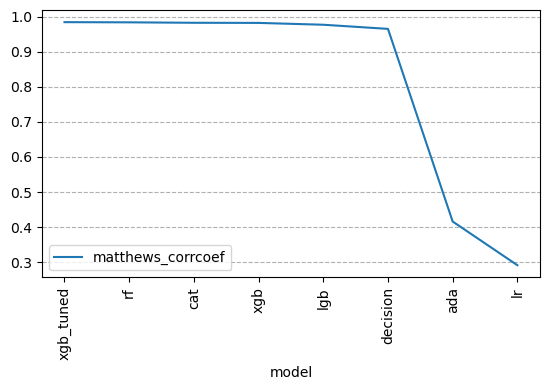

In [26]:
# plot initial results
plot_model_metrics(test_results, primary_metric)

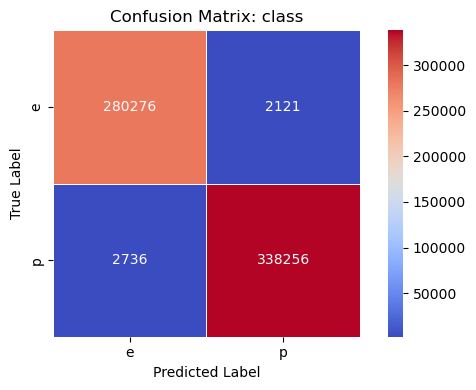

In [27]:
# plot confusion matrix
plot_confusion_matrix(
    cm=confusion_matrices[tuned_model_name],
    target=target,
    class_labels=target_classes,
)

In [28]:
# make predictions and probabilties
test_pred = final_model.predict(test_data)
test_pred_proba = final_model.predict_proba(test_data)[:, 1]
decoded_pred = target_encoder.inverse_transform(test_pred.ravel())

# write to submissions file
sub_data[target] = decoded_pred
sub_data.to_csv("submission.csv", index=True, index_label=index_col)

pd.read_csv("submission.csv")

,id,class
0,3116945,e
1,3116946,p
2,3116947,p
3,3116948,p
4,3116949,e
...,...,...
2077959,5194904,p
2077960,5194905,p
2077961,5194906,p
2077962,5194907,e


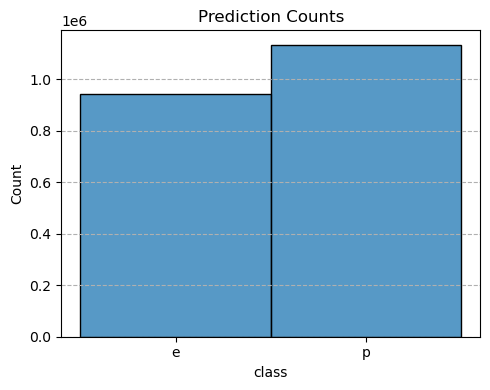

In [ ]:
# plot predictions
plot_predictions(sub_data[target])